In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("✅ Dataset loaded successfully!")
print("File name:", filename)
print("Dataset shape:", df.shape)

print("\n📌 Column names:")
print(df.columns.tolist())

print("\n📌 First 5 rows:")
display(df.head())

print("\n📌 Missing values:")
print(df.isnull().sum())

Saving skin_disease_symptoms.csv to skin_disease_symptoms (27).csv
✅ Dataset loaded successfully!
File name: skin_disease_symptoms (27).csv
Dataset shape: (35, 6)

📌 Column names:
['Disease Name', 'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']

📌 First 5 rows:


,Disease Name,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
0,Acne,Pimples,Blackheads,Redness,Oily skin,Whiteheads
1,Eczema (Dermatitis),Itching,Redness,Dryness,Scaling,Crusting
2,Psoriasis,Red patches,Scaling,Itching,Thickened skin,Nail changes
3,Rosacea,Facial redness,Swollen red bumps,Visible blood vessels,Eye irritation,Thickening of skin
4,Dermatitis Herpetiformis,Intense itching,Blisters,Red bumps,Symmetrical distribution,Grouped lesions



📌 Missing values:
Disease Name    0
Symptom 1       0
Symptom 2       0
Symptom 3       0
Symptom 4       0
Symptom 5       0
dtype: int64


In [ ]:
# Check dataset information

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nFirst 10 Rows:")
display(df.head(10))

Dataset Shape: (35, 6)

Column Names:
['Disease Name', 'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Disease Name  35 non-null     object
 1   Symptom 1     35 non-null     object
 2   Symptom 2     35 non-null     object
 3   Symptom 3     35 non-null     object
 4   Symptom 4     35 non-null     object
 5   Symptom 5     35 non-null     object
dtypes: object(6)
memory usage: 1.8+ KB

First 10 Rows:


,Disease Name,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
0,Acne,Pimples,Blackheads,Redness,Oily skin,Whiteheads
1,Eczema (Dermatitis),Itching,Redness,Dryness,Scaling,Crusting
2,Psoriasis,Red patches,Scaling,Itching,Thickened skin,Nail changes
3,Rosacea,Facial redness,Swollen red bumps,Visible blood vessels,Eye irritation,Thickening of skin
4,Dermatitis Herpetiformis,Intense itching,Blisters,Red bumps,Symmetrical distribution,Grouped lesions
5,Urticaria (Hives),Raised welts,Itching,Redness,Swelling,Varies in size
6,Contact Dermatitis,Redness,Itching,Swelling,Blistering,Burning sensation
7,Fungal Infections,Redness,Itching,Scaling,Cracking,Pustules
8,Viral Infections,Lesions,Rash,Blisters,Itching,Pain or discomfort
9,Bacterial Infections,Redness,Swelling,Pus-filled blisters,Pain,Warmth


In [ ]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
Disease Name    0
Symptom 1       0
Symptom 2       0
Symptom 3       0
Symptom 4       0
Symptom 5       0
dtype: int64

Total missing values: 0


In [ ]:
# Remove completely empty columns
df = df.dropna(axis=1, how="all")

# Remove automatically generated unnamed index columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("Columns after cleaning:")
print(df.columns.tolist())

print("\nNew shape:", df.shape)

Columns after cleaning:
['Disease Name', 'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']

New shape: (35, 6)


In [ ]:
# Display columns and their number of unique values

for column in df.columns:
    print(f"{column} -> {df[column].nunique()} unique values")

print("\nPossible target columns are usually the column containing disease/class labels.")

Disease Name -> 35 unique values
Symptom 1 -> 28 unique values
Symptom 2 -> 29 unique values
Symptom 3 -> 26 unique values
Symptom 4 -> 33 unique values
Symptom 5 -> 30 unique values

Possible target columns are usually the column containing disease/class labels.


In [ ]:
# Show the EXACT column names from your CSV

print("Exact column names:")

for i, col in enumerate(df.columns):
    print(i, repr(col))

Exact column names:
0 'Disease Name'
1 'Symptom 1'
2 'Symptom 2'
3 'Symptom 3'
4 'Symptom 4'
5 'Symptom 5'


In [ ]:
# Clean column names
df.columns = df.columns.astype(str).str.strip()

print("Columns:")
print(df.columns.tolist())

print("\nDataset shape:", df.shape)

display(df.head())

Columns:
['Disease Name', 'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']

Dataset shape: (35, 6)


,Disease Name,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
0,Acne,Pimples,Blackheads,Redness,Oily skin,Whiteheads
1,Eczema (Dermatitis),Itching,Redness,Dryness,Scaling,Crusting
2,Psoriasis,Red patches,Scaling,Itching,Thickened skin,Nail changes
3,Rosacea,Facial redness,Swollen red bumps,Visible blood vessels,Eye irritation,Thickening of skin
4,Dermatitis Herpetiformis,Intense itching,Blisters,Red bumps,Symmetrical distribution,Grouped lesions


In [ ]:
TARGET_COLUMN = "Disease Name"

print("Target column:", TARGET_COLUMN)

print("\nNumber of disease classes:")
print(df[TARGET_COLUMN].nunique())

print("\nDisease classes:")
print(df[TARGET_COLUMN].unique())

print("\nNumber of samples for each disease:")
print(df[TARGET_COLUMN].value_counts())

Target column: Disease Name

Number of disease classes:
35

Disease classes:
['Acne' 'Eczema (Dermatitis)' 'Psoriasis' 'Rosacea'
 'Dermatitis Herpetiformis' 'Urticaria (Hives)' 'Contact Dermatitis'
 'Fungal Infections' 'Viral Infections' 'Bacterial Infections' 'Scabies'
 'Lichen Planus' 'Vitiligo' 'Melanoma' 'Basal Cell Carcinoma (BCC)'
 'Squamous Cell Carcinoma (SCC)' 'Pityriasis Rosea' 'Prurigo Nodularis'
 'Keratosis Pilaris' 'Ichthyosis' 'Actinic Keratosis' 'Granuloma Annulare'
 'Pemphigus' 'Pemphigoid' 'Lupus Erythematosus' 'Necrobiosis Lipoidica'
 'Cutaneous T-cell Lymphoma' 'Morphea' 'Erythema Multiforme'
 'Alopecia Areata' 'Epidermolysis Bullosa' 'Angioedema'
 'Pyoderma Gangrenosum' "Sweet's Syndrome" 'Dermatofibroma']

Number of samples for each disease:
Disease Name
Acne                             1
Eczema (Dermatitis)              1
Psoriasis                        1
Rosacea                          1
Dermatitis Herpetiformis         1
Urticaria (Hives)                1
Cont

In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Disease Name    0
Symptom 1       0
Symptom 2       0
Symptom 3       0
Symptom 4       0
Symptom 5       0
dtype: int64


In [ ]:
# Fill missing values

symptom_columns = [
    "Symptom 1",
    "Symptom 2",
    "Symptom 3",
    "Symptom 4",
    "Symptom 5"
]

df[symptom_columns] = df[symptom_columns].fillna("Unknown")

df[TARGET_COLUMN] = df[TARGET_COLUMN].fillna("Unknown")

print("✅ Missing values handled.")

print(df.isnull().sum())

✅ Missing values handled.
Disease Name    0
Symptom 1       0
Symptom 2       0
Symptom 3       0
Symptom 4       0
Symptom 5       0
dtype: int64


In [ ]:
# Clean text values

for column in symptom_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

df[TARGET_COLUMN] = (
    df[TARGET_COLUMN]
    .astype(str)
    .str.strip()
)

print("✅ Text values cleaned.")

display(df.head())

✅ Text values cleaned.


,Disease Name,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
0,Acne,pimples,blackheads,redness,oily skin,whiteheads
1,Eczema (Dermatitis),itching,redness,dryness,scaling,crusting
2,Psoriasis,red patches,scaling,itching,thickened skin,nail changes
3,Rosacea,facial redness,swollen red bumps,visible blood vessels,eye irritation,thickening of skin
4,Dermatitis Herpetiformis,intense itching,blisters,red bumps,symmetrical distribution,grouped lesions


In [ ]:
from sklearn.preprocessing import OneHotEncoder

X = df[symptom_columns]
y = df[TARGET_COLUMN]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_encoded = encoder.fit_transform(X)

print("✅ Symptoms converted into numerical features.")

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

✅ Symptoms converted into numerical features.
Original X shape: (35, 5)
Encoded X shape: (35, 146)


In [ ]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

print("✅ Disease names encoded.")

print("\nDisease classes:")

for number, disease in enumerate(target_encoder.classes_):
    print(number, "=", disease)

✅ Disease names encoded.

Disease classes:
0 = Acne
1 = Actinic Keratosis
2 = Alopecia Areata
3 = Angioedema
4 = Bacterial Infections
5 = Basal Cell Carcinoma (BCC)
6 = Contact Dermatitis
7 = Cutaneous T-cell Lymphoma
8 = Dermatitis Herpetiformis
9 = Dermatofibroma
10 = Eczema (Dermatitis)
11 = Epidermolysis Bullosa
12 = Erythema Multiforme
13 = Fungal Infections
14 = Granuloma Annulare
15 = Ichthyosis
16 = Keratosis Pilaris
17 = Lichen Planus
18 = Lupus Erythematosus
19 = Melanoma
20 = Morphea
21 = Necrobiosis Lipoidica
22 = Pemphigoid
23 = Pemphigus
24 = Pityriasis Rosea
25 = Prurigo Nodularis
26 = Psoriasis
27 = Pyoderma Gangrenosum
28 = Rosacea
29 = Scabies
30 = Squamous Cell Carcinoma (SCC)
31 = Sweet's Syndrome
32 = Urticaria (Hives)
33 = Viral Infections
34 = Vitiligo


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Check how many samples each disease has
unique_classes, class_counts = np.unique(y_encoded, return_counts=True)

print("Samples per disease:")
for class_id, count in zip(unique_classes, class_counts):
    disease = target_encoder.inverse_transform([class_id])[0]
    print(f"{disease}: {count}")

# Check whether every class has at least 2 samples
if np.min(class_counts) >= 2:

    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded,
        y_encoded,
        test_size=0.20,
        random_state=42,
        stratify=y_encoded
    )

else:

    print("\n⚠️ Some disease classes have only 1 sample.")
    print("Using a non-stratified split instead.")

    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded,
        y_encoded,
        test_size=0.20,
        random_state=42
    )

print("\n✅ Data split successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Samples per disease:
Acne: 1
Actinic Keratosis: 1
Alopecia Areata: 1
Angioedema: 1
Bacterial Infections: 1
Basal Cell Carcinoma (BCC): 1
Contact Dermatitis: 1
Cutaneous T-cell Lymphoma: 1
Dermatitis Herpetiformis: 1
Dermatofibroma: 1
Eczema (Dermatitis): 1
Epidermolysis Bullosa: 1
Erythema Multiforme: 1
Fungal Infections: 1
Granuloma Annulare: 1
Ichthyosis: 1
Keratosis Pilaris: 1
Lichen Planus: 1
Lupus Erythematosus: 1
Melanoma: 1
Morphea: 1
Necrobiosis Lipoidica: 1
Pemphigoid: 1
Pemphigus: 1
Pityriasis Rosea: 1
Prurigo Nodularis: 1
Psoriasis: 1
Pyoderma Gangrenosum: 1
Rosacea: 1
Scabies: 1
Squamous Cell Carcinoma (SCC): 1
Sweet's Syndrome: 1
Urticaria (Hives): 1
Viral Infections: 1
Vitiligo: 1

⚠️ Some disease classes have only 1 sample.
Using a non-stratified split instead.

✅ Data split successfully!
Training samples: 28
Testing samples: 7


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("====================================")
print("       MODEL PERFORMANCE")
print("====================================")
print("Accuracy:", round(accuracy * 100, 2), "%")

       MODEL PERFORMANCE
Accuracy: 0.0 %


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Find the classes actually present in the test data
labels_present = np.unique(np.concatenate([y_test, y_pred]))

# Get only the corresponding disease names
target_names_present = target_encoder.inverse_transform(labels_present)

print("====================================")
print("       CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_test,
        y_pred,
        labels=labels_present,
        target_names=target_names_present,
        zero_division=0
    )
)

       CLASSIFICATION REPORT
                               precision    recall  f1-score   support

              Alopecia Areata       0.00      0.00      0.00       1.0
    Cutaneous T-cell Lymphoma       0.00      0.00      0.00       1.0
          Eczema (Dermatitis)       0.00      0.00      0.00       0.0
           Granuloma Annulare       0.00      0.00      0.00       1.0
                   Ichthyosis       0.00      0.00      0.00       1.0
          Lupus Erythematosus       0.00      0.00      0.00       1.0
                     Melanoma       0.00      0.00      0.00       1.0
                      Morphea       0.00      0.00      0.00       0.0
             Pityriasis Rosea       0.00      0.00      0.00       0.0
                    Psoriasis       0.00      0.00      0.00       0.0
         Pyoderma Gangrenosum       0.00      0.00      0.00       0.0
Squamous Cell Carcinoma (SCC)       0.00      0.00      0.00       1.0

                     accuracy                 

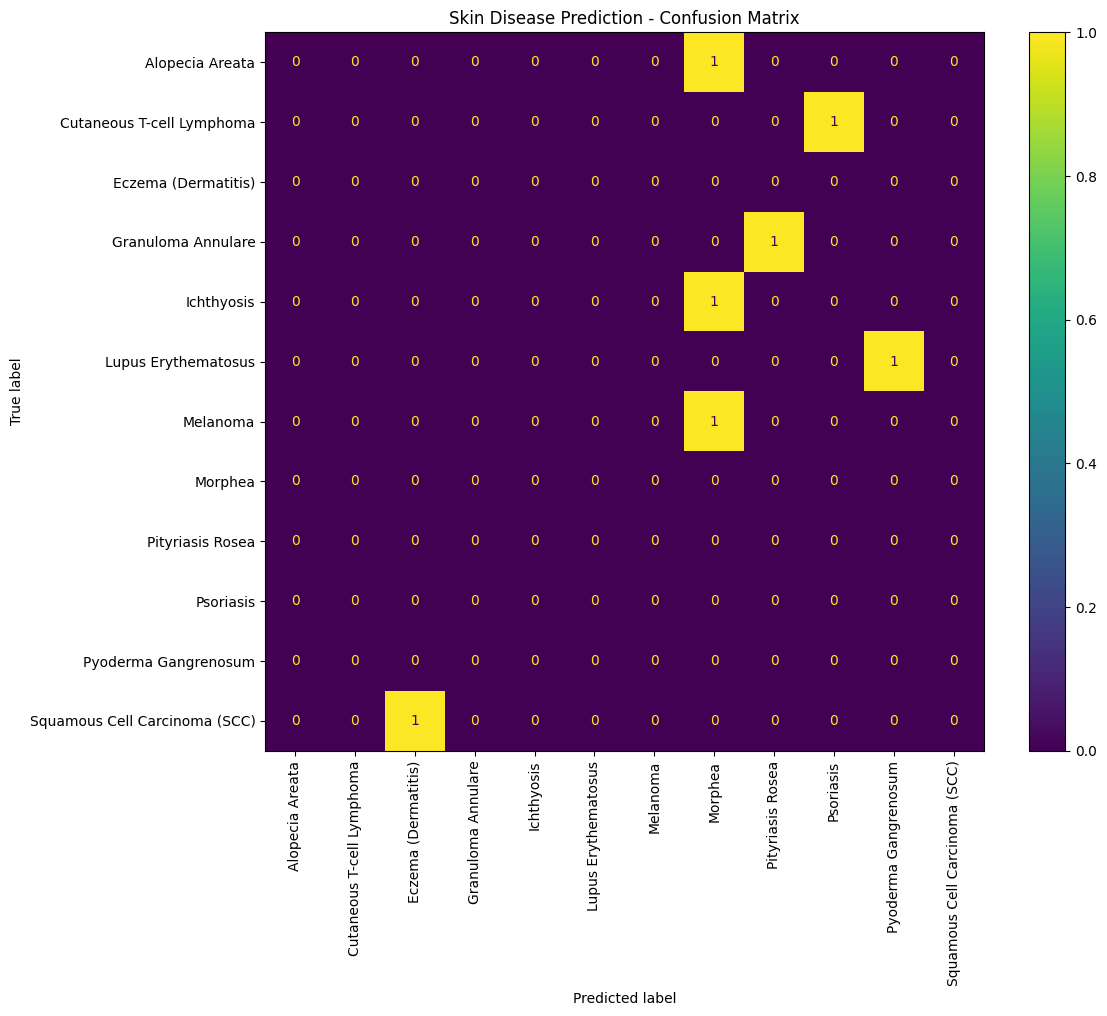

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

labels_present = np.unique(np.concatenate([y_test, y_pred]))
names_present = target_encoder.inverse_transform(labels_present)

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=labels_present,
    display_labels=names_present,
    xticks_rotation=90,
    ax=ax
)

ax.set_title("Skin Disease Prediction - Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# Example patient symptoms
patient = pd.DataFrame({
    "Symptom 1": ["itching"],
    "Symptom 2": ["skin rash"],
    "Symptom 3": ["nodal skin eruptions"],
    "Symptom 4": ["dischromic patches"],
    "Symptom 5": ["Unknown"]
})

# Clean patient input
for column in symptom_columns:
    patient[column] = (
        patient[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

# Convert symptoms using the SAME encoder
patient_encoded = encoder.transform(patient[symptom_columns])

# Prediction
prediction = model.predict(patient_encoded)[0]

# Probability
probabilities = model.predict_proba(patient_encoded)[0]

predicted_disease = target_encoder.inverse_transform(
    [prediction]
)[0]

confidence = probabilities[prediction] * 100

print("====================================")
print("       SKIN DISEASE PREDICTION")
print("====================================")
print("Predicted Disease:", predicted_disease)
print("Confidence:", round(confidence, 2), "%")
print("====================================")

       SKIN DISEASE PREDICTION
Predicted Disease: Eczema (Dermatitis)
Confidence: 1.33 %


In [ ]:
import joblib

joblib.dump(model, "skin_disease_model.pkl")
joblib.dump(encoder, "skin_symptom_encoder.pkl")
joblib.dump(target_encoder, "skin_disease_encoder.pkl")

print("✅ All model files saved successfully!")

✅ All model files saved successfully!


In [ ]:
from google.colab import files

files.download("skin_disease_model.pkl")
files.download("skin_symptom_encoder.pkl")
files.download("skin_disease_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>